# Perbandingan Metode Fuzzy Mamdani dan Sugeno untuk Estimasi Harga Properti
**Dataset:** [Zameen Dataset](https://www.kaggle.com/datasets/jillanisofttech/pakistan-house-price-dataset)

## 1. Import Modul Standar

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report, confusion_matrix

## 2. Persiapan Data dan Fungsi Keanggotaan

In [11]:
df = pd.read_csv('zameen-updated-sample50k.csv')
df = df.dropna(subset=['price', 'Area Size', 'Area Type', 'bedrooms', 'baths', 'property_type', 'city'])

def convert_to_marla(row):
    if row['Area Type'] == 'Kanal':
        return row['Area Size'] * 20
    return row['Area Size']
df['Area_Marla'] = df.apply(convert_to_marla, axis=1)

# Batasan harga: Minimum 1.000 dan Maksimum 2.250.000 PKR
df = df[(df['price'] >= 1000) & (df['price'] <= 2.25e6)]

def get_property_score(ptype):
    ptype = str(ptype).lower()
    if 'farm' in ptype or 'penthouse' in ptype: return 10
    elif 'house' in ptype: return 8
    elif 'flat' in ptype or 'apartment' in ptype: return 6
    else: return 3
df['Property_Score'] = df['property_type'].apply(get_property_score)

def get_location_score(city):
    city = str(city).lower()
    if 'islamabad' in city: return 90
    elif 'lahore' in city or 'karachi' in city: return 80
    elif 'rawalpindi' in city or 'faisalabad' in city: return 60
    else: return 40
df['Location_Score'] = df['city'].apply(get_location_score)

def trapmf(x, abcd):
    a, b, c, d = abcd
    
    if isinstance(x, (list, np.ndarray)):
        y = np.zeros(len(x))
        for i in range(len(x)):
            if x[i] <= a or x[i] >= d: y[i] = 0.0
            elif a < x[i] < b: y[i] = (x[i] - a) / (b - a) if b != a else 1.0
            elif b <= x[i] <= c: y[i] = 1.0
            elif c < x[i] < d: y[i] = (d - x[i]) / (d - c) if d != c else 1.0
        return y
        
    else:
        if x <= a or x >= d: return 0.0
        elif a < x < b: return (x - a) / (b - a) if b != a else 1.0
        elif b <= x <= c: return 1.0
        elif c < x < d: return (d - x) / (d - c) if d != c else 1.0
        return 0.0

def trimf(x, abc):
    return trapmf(x, [abc[0], abc[1], abc[1], abc[2]])

def fuzzify_area(x): return {'Kecil': trapmf(x, [0, 0, 8, 15]), 'Sedang': trimf(x, [10, 20, 30]), 'Luas': trapmf(x, [20, 40, 160, 160])}
def fuzzify_bed(x): return {'Sedikit': trapmf(x, [0, 0, 2, 5]), 'Sedang': trimf(x, [3, 5, 8]), 'Banyak': trapmf(x, [6, 9, 28, 28])}
def fuzzify_bath(x): return {'Sedikit': trapmf(x, [0, 0, 2, 4]), 'Sedang': trimf(x, [3, 5, 7]), 'Banyak': trapmf(x, [6, 8, 14, 14])}
def fuzzify_prop(x): return {'Sederhana': trapmf(x, [0, 0, 3, 5]), 'Menengah': trimf(x, [4, 6, 8]), 'Mewah': trapmf(x, [7, 9, 10, 10])}
def fuzzify_loc(x): return {'Biasa': trapmf(x, [0, 0, 40, 50]), 'Strategis': trimf(x, [40, 65, 85]), 'Sangat Strategis': trapmf(x, [80, 90, 100, 100])}

C:\Users\voliya\AppData\Local\Temp\ipykernel_2116\3257804242.py:1: DtypeWarning: Columns (0: page_url, 1: property_type, 2: location, 3: city, 4: province_name, 5: area, 6: purpose, 7: date_added, 8: agency, 9: agent, 10: Area Type, 11: Area Category) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('zameen-updated-sample50k.csv')


### Visualisasi Membership Functions

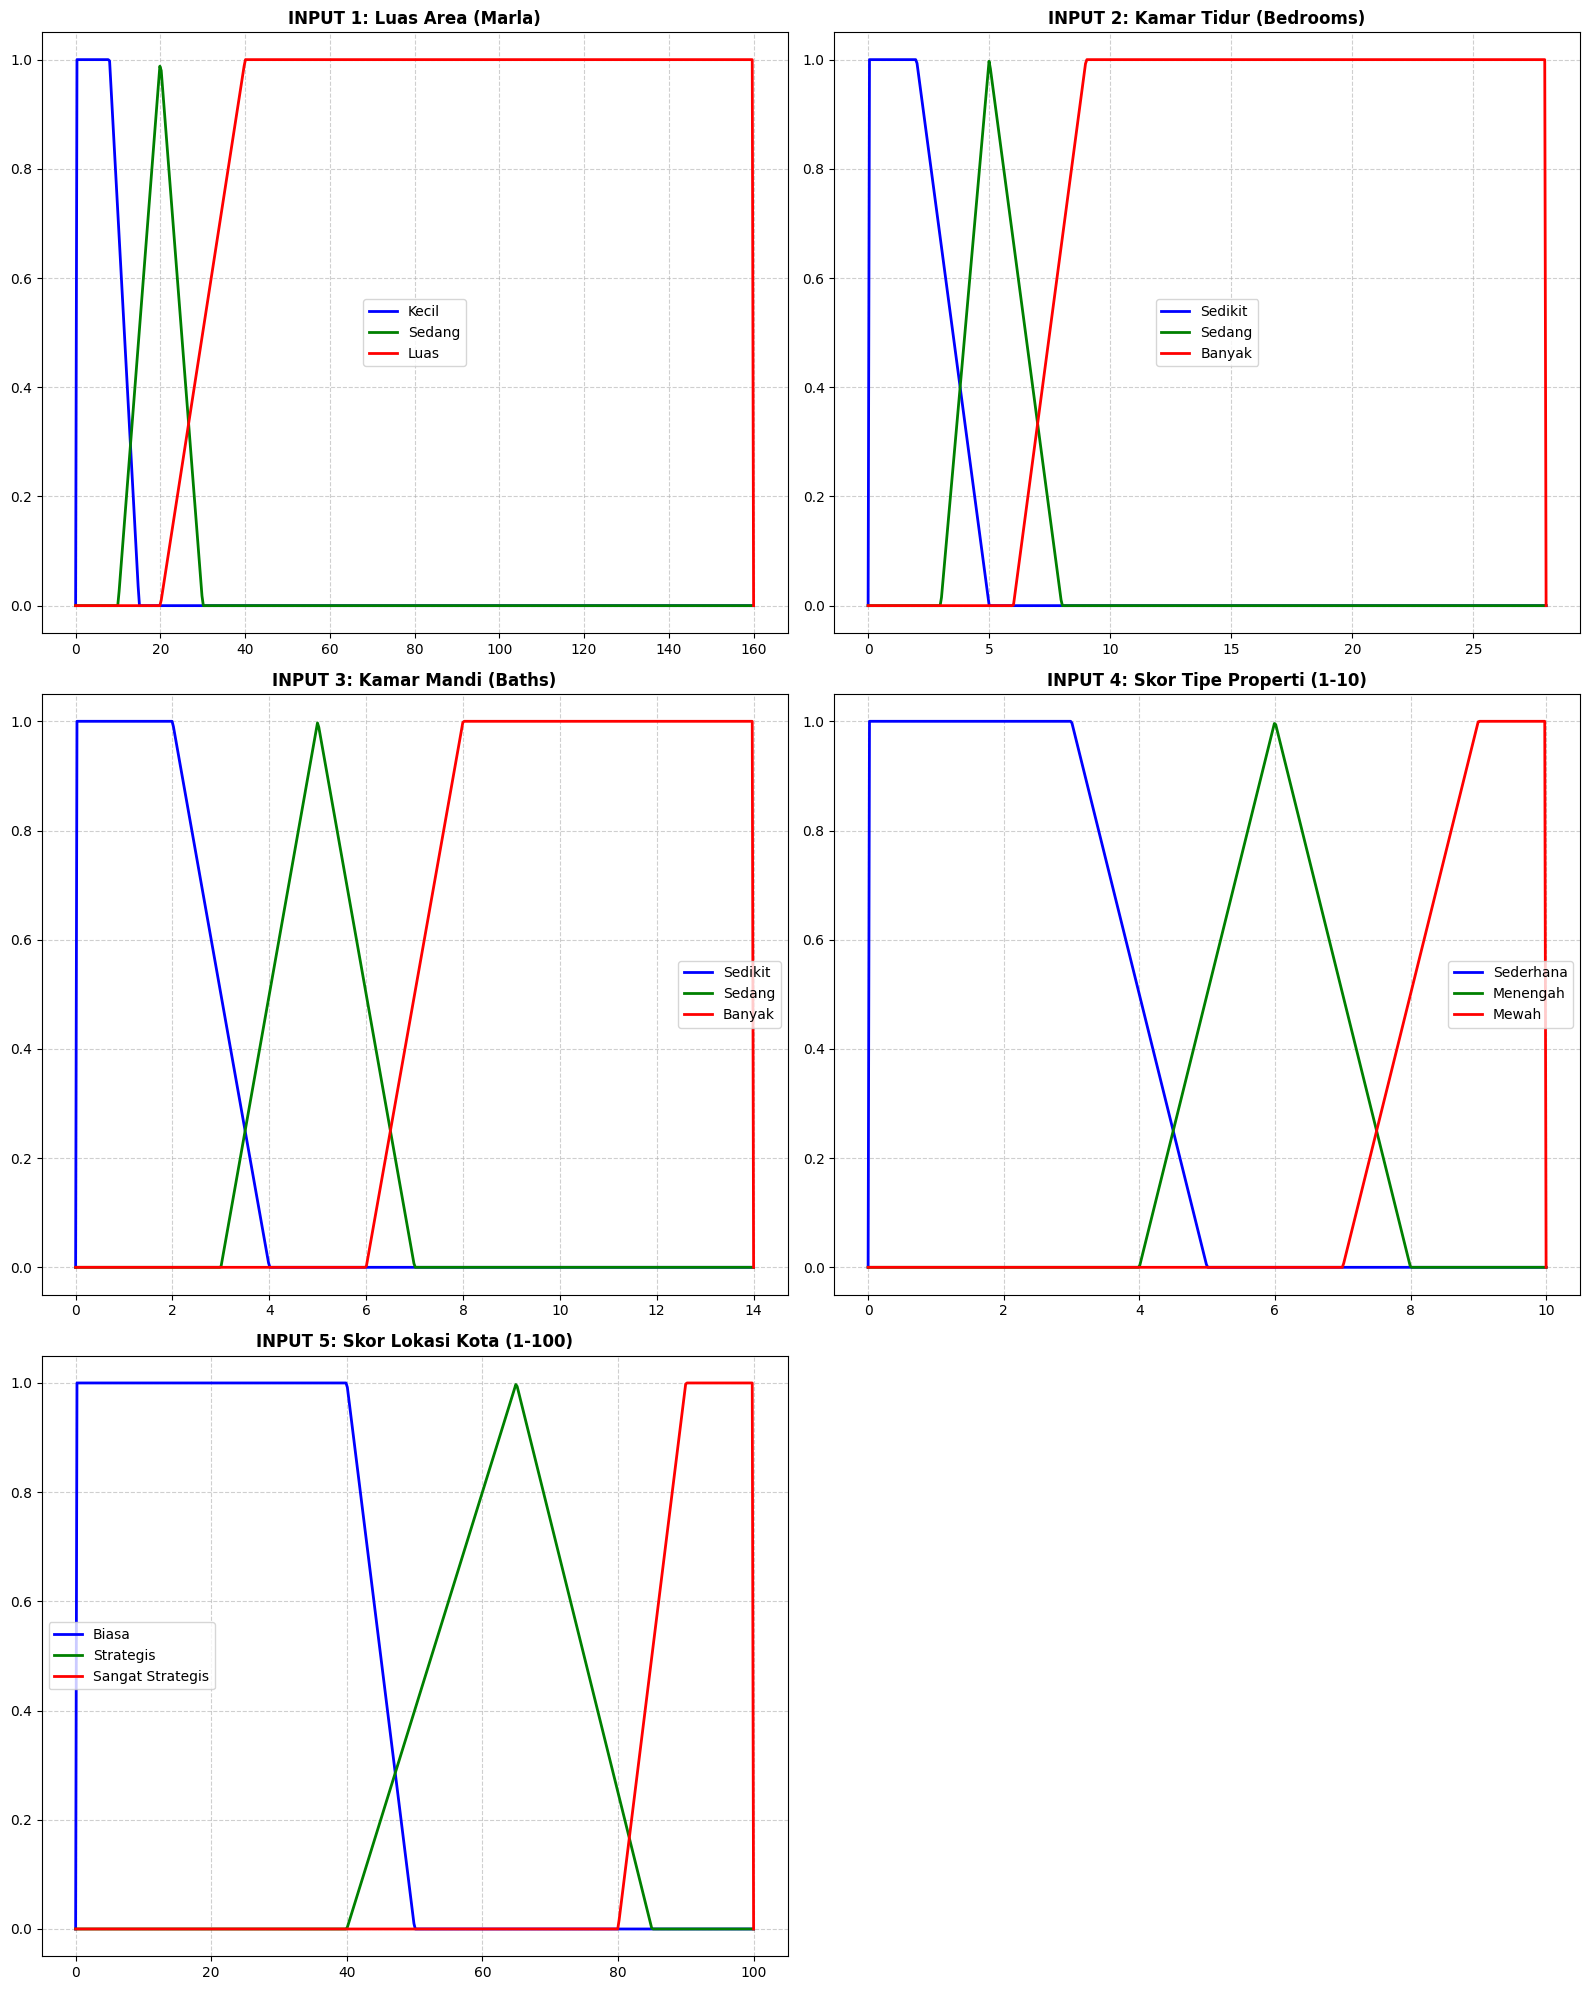

In [12]:
def plot_membership_functions():
    fig, axs = plt.subplots(3, 2, figsize=(16, 20))
    plt.subplots_adjust(hspace=0.4, wspace=0.2)

    x_area = np.linspace(0, 160, 500)
    axs[0, 0].plot(x_area, trapmf(x_area, [0, 0, 8, 15]), label='Kecil', color='blue', linewidth=2)
    axs[0, 0].plot(x_area, trimf(x_area, [10, 20, 30]), label='Sedang', color='green', linewidth=2)
    axs[0, 0].plot(x_area, trapmf(x_area, [20, 40, 160, 160]), label='Luas', color='red', linewidth=2)
    axs[0, 0].set_title('INPUT 1: Luas Area (Marla)', fontsize=12, fontweight='bold')
    axs[0, 0].legend(); axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    x_bed = np.linspace(0, 28, 500)
    axs[0, 1].plot(x_bed, trapmf(x_bed, [0, 0, 2, 5]), label='Sedikit', color='blue', linewidth=2)
    axs[0, 1].plot(x_bed, trimf(x_bed, [3, 5, 8]), label='Sedang', color='green', linewidth=2)
    axs[0, 1].plot(x_bed, trapmf(x_bed, [6, 9, 28, 28]), label='Banyak', color='red', linewidth=2)
    axs[0, 1].set_title('INPUT 2: Kamar Tidur (Bedrooms)', fontsize=12, fontweight='bold')
    axs[0, 1].legend(); axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    x_bath = np.linspace(0, 14, 500)
    axs[1, 0].plot(x_bath, trapmf(x_bath, [0, 0, 2, 4]), label='Sedikit', color='blue', linewidth=2)
    axs[1, 0].plot(x_bath, trimf(x_bath, [3, 5, 7]), label='Sedang', color='green', linewidth=2)
    axs[1, 0].plot(x_bath, trapmf(x_bath, [6, 8, 14, 14]), label='Banyak', color='red', linewidth=2)
    axs[1, 0].set_title('INPUT 3: Kamar Mandi (Baths)', fontsize=12, fontweight='bold')
    axs[1, 0].legend(); axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    x_prop = np.linspace(0, 10, 500)
    axs[1, 1].plot(x_prop, trapmf(x_prop, [0, 0, 3, 5]), label='Sederhana', color='blue', linewidth=2)
    axs[1, 1].plot(x_prop, trimf(x_prop, [4, 6, 8]), label='Menengah', color='green', linewidth=2)
    axs[1, 1].plot(x_prop, trapmf(x_prop, [7, 9, 10, 10]), label='Mewah', color='red', linewidth=2)
    axs[1, 1].set_title('INPUT 4: Skor Tipe Properti (1-10)', fontsize=12, fontweight='bold')
    axs[1, 1].legend(); axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    x_loc = np.linspace(0, 100, 500)
    axs[2, 0].plot(x_loc, trapmf(x_loc, [0, 0, 40, 50]), label='Biasa', color='blue', linewidth=2)
    axs[2, 0].plot(x_loc, trimf(x_loc, [40, 65, 85]), label='Strategis', color='green', linewidth=2)
    axs[2, 0].plot(x_loc, trapmf(x_loc, [80, 90, 100, 100]), label='Sangat Strategis', color='red', linewidth=2)
    axs[2, 0].set_title('INPUT 5: Skor Lokasi Kota (1-100)', fontsize=12, fontweight='bold')
    axs[2, 0].legend(); axs[2, 0].grid(True, linestyle='--', alpha=0.6)

    axs[2, 1].axis('off')

    plt.tight_layout()
    plt.show(block=False) 
    plt.pause(2) 

plot_membership_functions()

## 3. Evaluasi Rules

In [13]:
def eval_rules(f_area, f_bed, f_bath, f_prop, f_loc):
    rules = []
    
    # --- KELOMPOK 1: Area Kecil (5 Rules) ---
    rules.append( (min(f_area['Kecil'], f_bed['Sedikit'], f_bath['Sedikit'], f_prop['Sederhana'], f_loc['Biasa']), 'Sangat Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Sedikit'], f_prop['Sederhana'], f_loc['Strategis']), 'Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Sedang'], f_bath['Sedikit'], f_prop['Menengah']), 'Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Banyak'], f_prop['Menengah'], f_loc['Biasa']), 'Sedang') )
    rules.append( (min(f_area['Kecil'], f_prop['Mewah'], f_loc['Sangat Strategis']), 'Sedang') )

    # --- KELOMPOK 2: Area Sedang (6 Rules) ---
    rules.append( (min(f_area['Sedang'], f_bed['Sedikit'], f_bath['Sedikit'], f_prop['Sederhana']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_bath['Sedikit'], f_loc['Biasa']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_bath['Sedang'], f_prop['Menengah'], f_loc['Strategis']), 'Sedang') )
    rules.append( (min(f_area['Sedang'], f_bed['Banyak'], f_bath['Sedang'], f_prop['Menengah']), 'Sedang') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_prop['Mewah'], f_loc['Strategis']), 'Mahal') )
    rules.append( (min(f_area['Sedang'], f_bed['Banyak'], f_bath['Banyak'], f_loc['Sangat Strategis']), 'Mahal') )

    # --- KELOMPOK 3: Area Luas (6 Rules) ---
    rules.append( (min(f_area['Luas'], f_bed['Sedikit'], f_prop['Sederhana'], f_loc['Biasa']), 'Sedang') )
    rules.append( (min(f_area['Luas'], f_bed['Sedikit'], f_prop['Menengah'], f_loc['Strategis']), 'Sedang') )
    rules.append( (min(f_area['Luas'], f_bed['Sedang'], f_bath['Sedikit'], f_prop['Menengah']), 'Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Sedang'], f_bath['Sedang'], f_prop['Mewah'], f_loc['Strategis']), 'Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Banyak'], f_bath['Sedang'], f_prop['Mewah']), 'Sangat Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Banyak'], f_bath['Banyak'], f_prop['Menengah'], f_loc['Sangat Strategis']), 'Sangat Mahal') )

    # --- KELOMPOK 4: Kombinasi Silang / Kasus Ekstrem (3 Rules) ---
    rules.append( (min(f_prop['Mewah'], f_loc['Sangat Strategis'], f_bath['Banyak']), 'Sangat Mahal') )
    rules.append( (min(f_prop['Sederhana'], f_loc['Biasa'], f_bed['Banyak']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_prop['Mewah'], f_bath['Banyak']), 'Mahal') )

    agg = {'Sangat Murah': 0.0, 'Murah': 0.0, 'Sedang': 0.0, 'Mahal': 0.0, 'Sangat Mahal': 0.0}
    for w, out in rules:
        agg[out] = max(agg[out], w)
    return agg

## 4. Defuzzifikasi Mamdani & Sugeno

In [14]:
z_points_list = list(np.linspace(0, 2.25e6, 2251))

def defuzz_mamdani_manual(agg):
    num = 0.0
    den = 0.0
    for z in z_points_list:
        mu_sm  = trapmf(z, [0, 0, 3e5, 6e5])
        mu_m   = trimf(z, [4e5, 8e5, 1.2e6])
        mu_sd  = trimf(z, [1e6, 1.4e6, 1.8e6])
        mu_mh  = trimf(z, [1.5e6, 1.8e6, 2.1e6])
        mu_smh = trapmf(z, [1.9e6, 2.25e6, 2.25e6, 2.25e6])
        
        mu_z = max(
            min(agg['Sangat Murah'], mu_sm),
            min(agg['Murah'], mu_m),
            min(agg['Sedang'], mu_sd),
            min(agg['Mahal'], mu_mh),
            min(agg['Sangat Mahal'], mu_smh)
        )
        
        num += z * mu_z
        den += mu_z
        
    return num / den if den != 0 else 0.0

sugeno_const = {'Sangat Murah': 3e5, 'Murah': 8e5, 'Sedang': 1.4e6, 'Mahal': 1.8e6, 'Sangat Mahal': 2.15e6}

def defuzz_sugeno(agg):
    num = sum(w * sugeno_const[cat] for cat, w in agg.items())
    den = sum(agg.values())
    return num / den if den != 0 else 0.0

## 5. Simulasi

=== HASIL EVALUASI PREDIKSI FUZZY LOGIC ===
Mean Absolute Error (MAE) MAMDANI      : 451,812.72 PKR
Mean Absolute Error (MAE) SUGENO       : 453,367.03 PKR
------------------------------------------------------------
Akurasi Tebakan Kategori MAMDANI       : 62.90%
Akurasi Tebakan Kategori SUGENO        : 62.90%
Menampilkan Heatmap Confusion Matrix...


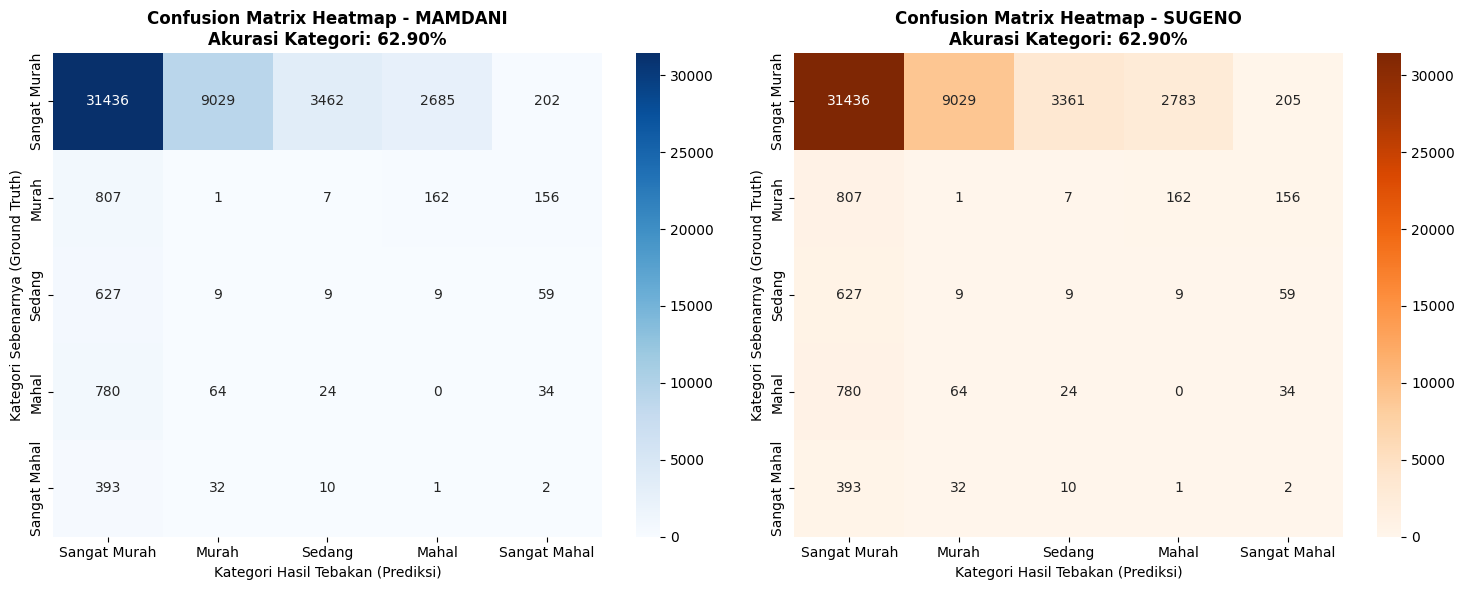

In [15]:
def get_crisp_category(price):
    cats = {
        'Sangat Murah': trapmf(price, [0, 0, 3e5, 6e5]),
        'Murah': trimf(price, [4e5, 8e5, 1.2e6]),
        'Sedang': trimf(price, [1e6, 1.4e6, 1.8e6]),
        'Mahal': trimf(price, [1.5e6, 1.8e6, 2.1e6]),
        'Sangat Mahal': trapmf(price, [1.9e6, 2.25e6, 2.25e6, 2.25e6])
    }
    max_cat = max(cats, key=cats.get)
    if cats[max_cat] == 0:
        if price <= 3e5: return 'Sangat Murah'
        elif price >= 1.9e6: return 'Sangat Mahal'
    return max_cat

results = []
y_actuals_num = []
y_pred_mamdani_num = []
y_pred_sugeno_num = []

for idx, row in df.iterrows():
    actual = row['price']
    
    f_a = fuzzify_area(row['Area_Marla'])
    f_bed = fuzzify_bed(row['bedrooms'])
    f_bath = fuzzify_bath(row['baths'])
    f_prop = fuzzify_prop(row['Property_Score'])
    f_loc = fuzzify_loc(row['Location_Score'])
    
    agg = eval_rules(f_a, f_bed, f_bath, f_prop, f_loc)
    
    m_pred = defuzz_mamdani_manual(agg)
    s_pred = defuzz_sugeno(agg)
    
    y_actuals_num.append(actual)
    y_pred_mamdani_num.append(m_pred)
    y_pred_sugeno_num.append(s_pred)
    
    actual_cat = get_crisp_category(actual)
    m_cat = get_crisp_category(m_pred)
    s_cat = get_crisp_category(s_pred)
    
    results.append({
        'Kategori Asli': actual_cat,
        'Mamdani Kategori': m_cat,
        'Sugeno Kategori': s_cat
    })

res_df = pd.DataFrame(results)

mae_mamdani = mean_absolute_error(y_actuals_num, y_pred_mamdani_num)
mae_sugeno = mean_absolute_error(y_actuals_num, y_pred_sugeno_num)

y_true_cat = res_df['Kategori Asli'].tolist()
y_pred_mamdani_cat = res_df['Mamdani Kategori'].tolist()
y_pred_sugeno_cat = res_df['Sugeno Kategori'].tolist()

acc_mamdani = accuracy_score(y_true_cat, y_pred_mamdani_cat) * 100
acc_sugeno = accuracy_score(y_true_cat, y_pred_sugeno_cat) * 100

print("="*60)
print("=== HASIL EVALUASI PREDIKSI FUZZY LOGIC ===")
print("="*60)
print(f"Mean Absolute Error (MAE) MAMDANI      : {mae_mamdani:,.2f} PKR")
print(f"Mean Absolute Error (MAE) SUGENO       : {mae_sugeno:,.2f} PKR")
print("-"*60)
print(f"Akurasi Tebakan Kategori MAMDANI       : {acc_mamdani:.2f}%")
print(f"Akurasi Tebakan Kategori SUGENO        : {acc_sugeno:.2f}%")
print("="*60)


# VISUALISASI HEATMAP CONFUSION MATRIX
# Membuat matriks pembaca berdasarkan urutan tingkatan harga yang logis
print("Menampilkan Heatmap Confusion Matrix...")
labels = ['Sangat Murah', 'Murah', 'Sedang', 'Mahal', 'Sangat Mahal']
cm_mamdani = confusion_matrix(y_true_cat, y_pred_mamdani_cat, labels=labels)
cm_sugeno = confusion_matrix(y_true_cat, y_pred_sugeno_cat, labels=labels)

fig2, ax2 = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_mamdani, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax2[0])
ax2[0].set_title('Confusion Matrix Heatmap - MAMDANI\nAkurasi Kategori: {:.2f}%'.format(acc_mamdani), fontweight='bold')
ax2[0].set_xlabel('Kategori Hasil Tebakan (Prediksi)')
ax2[0].set_ylabel('Kategori Sebenarnya (Ground Truth)')

sns.heatmap(cm_sugeno, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax2[1])
ax2[1].set_title('Confusion Matrix Heatmap - SUGENO\nAkurasi Kategori: {:.2f}%'.format(acc_sugeno), fontweight='bold')
ax2[1].set_xlabel('Kategori Hasil Tebakan (Prediksi)')
ax2[1].set_ylabel('Kategori Sebenarnya (Ground Truth)')

plt.tight_layout()
plt.show()